In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
results = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\forecast_results_3.csv"   # for total server data: use cpu_features.csv
)

print(results.shape)
results.head()

results['Timestamp'] = pd.to_datetime(
    results['Timestamp'],
    format='mixed',
    utc=True
)

results = results.sort_values(
    'Timestamp'
).reset_index(drop=True)

print(results.dtypes)

(4917, 11)
host_id                                int64
hostName                              object
Timestamp                datetime64[ns, UTC]
cpu_usage_pct                        float64
Actual_1hr                           float64
Predicted_1hr                        float64
memory_usage_pct                     float64
power_kw                             float64
cpu_temp_c                             int64
inlet_temp_c                           int64
resource_stress_index                float64
dtype: object


In [3]:
# Forecast error
results['forecast_error'] = (
    results['Actual_1hr'] - results['Predicted_1hr']
).abs()
results.head()


,host_id,hostName,Timestamp,cpu_usage_pct,Actual_1hr,Predicted_1hr,memory_usage_pct,power_kw,cpu_temp_c,inlet_temp_c,resource_stress_index,forecast_error
0,3,10.10.10.2,2026-05-25 01:54:19.936000+00:00,28.0,28.0,28.021881,27.0,0.211,47,26,27.0,0.021881
1,3,10.10.10.2,2026-05-25 01:59:16.907000+00:00,27.0,27.0,28.212920,27.0,0.210,47,22,28.0,1.212920
2,3,10.10.10.2,2026-05-25 02:04:19.360000+00:00,27.0,27.0,27.738323,27.0,0.211,43,18,28.5,0.738323
3,3,10.10.10.2,2026-05-25 02:09:18.002000+00:00,27.0,27.0,27.651306,27.0,0.214,44,23,27.0,0.651306
4,3,10.10.10.2,2026-05-25 02:14:19.190000+00:00,28.0,28.0,28.146212,27.0,0.212,47,25,28.0,0.146212


In [4]:
df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\forecast_results_3.csv"
)
print(df.shape)
df['ts'] = pd.to_datetime(
    df['Timestamp'],
    format='mixed',
    utc=True
)
df = df.sort_values(
    ['host_id','ts']
)

(4917, 11)


In [5]:
SERVER_ID = 3
df = df[
    df['host_id'] == SERVER_ID
].copy()
SERVER_NAME = df['hostName'].iloc[0]
print("Server:", SERVER_NAME)
print(df.shape)

Server: 10.10.10.2
(4917, 12)


In [6]:
iso_features = [
    'Actual_1hr',
]

X_iso = df[
    iso_features
]

print(X_iso.shape)

(4917, 1)


In [7]:
# Train isolation forest
iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.001,
    random_state=42
)
iso_model.fit(
    X_iso
)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.001
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [8]:
# Predict anomalies
df['iso_label'] = (
    iso_model.predict(X_iso)
)
# iso_model.predict(X_iso) returns:
# 1 → normal (inlier)
# -1 → anomaly (outlier)
df['iso_anomaly'] = (
    df['iso_label'] == -1
)   # creates true/false column: True(anomaly -1)/False(normal 1)
print(
    "Total anomalies:",
    df['iso_anomaly'].sum()
)
print(
    df['iso_anomaly']
    .value_counts()
)

Total anomalies: 5
iso_anomaly
False    4912
True        5
Name: count, dtype: int64


In [9]:
anomaly_table = df[
    df['iso_anomaly']
].copy()

anomaly_table = anomaly_table[
    [
        'host_id',
        'hostName',
        'ts',
        'Actual_1hr',
        'Predicted_1hr'
    ]
]
anomaly_table = anomaly_table.sort_values(
    'ts'
)
display(
    anomaly_table.head(100)
)

,host_id,hostName,ts,Actual_1hr,Predicted_1hr
1405,3,10.10.10.2,2026-05-29 22:59:18.624000+00:00,36.00,28.345755
3410,3,10.10.10.2,2026-06-05 22:01:14.436000+00:00,35.04,30.765562
3438,3,10.10.10.2,2026-06-06 00:21:11.894000+00:00,35.09,30.818802
3617,3,10.10.10.2,2026-06-06 15:16:14.139000+00:00,35.69,29.916110
4663,3,10.10.10.2,2026-06-10 06:30:05.714000+00:00,36.42,28.279951


In [10]:
import sys
!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# =====================================
# INTERACTIVE FUTURE ANOMALY PLOT
# =====================================

import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

anomalies = df[
    df['iso_anomaly']
].copy()

fig = go.Figure()

# Predicted CPU Line
fig.add_trace(
    go.Scatter(
        x=df['ts'],
        y=df['Actual_1hr'],
        mode='lines',
        name='Predicted CPU',
        line=dict(width=1)
    )
)

# Future anomaly markers
fig.add_trace(
    go.Scatter(
        x=anomalies['ts'],
        y=anomalies['Actual_1hr'],
        mode='markers+text',
        name='Future Anomaly',

        marker=dict(
            color='red',
            size=12,
            line=dict(
                color='black',
                width=1
            )
        ),

        text=[
            ts.strftime("%d-%m-%Y %H:%M")
            for ts in anomalies['ts']
        ],

        textposition="top center",

        hovertemplate=
        "<b>Timestamp:</b> %{text}<br>" +
        "<b>Predicted CPU:</b> %{y:.2f}%<br>" +
        "<extra></extra>"
    )
)

fig.update_layout(

    title=
    f"{SERVER_NAME} | CPU Anomalies",

    xaxis_title="Timestamp",

    yaxis_title="Actual CPU Usage (%)",

    hovermode='closest',

    height=850
)

fig.show()

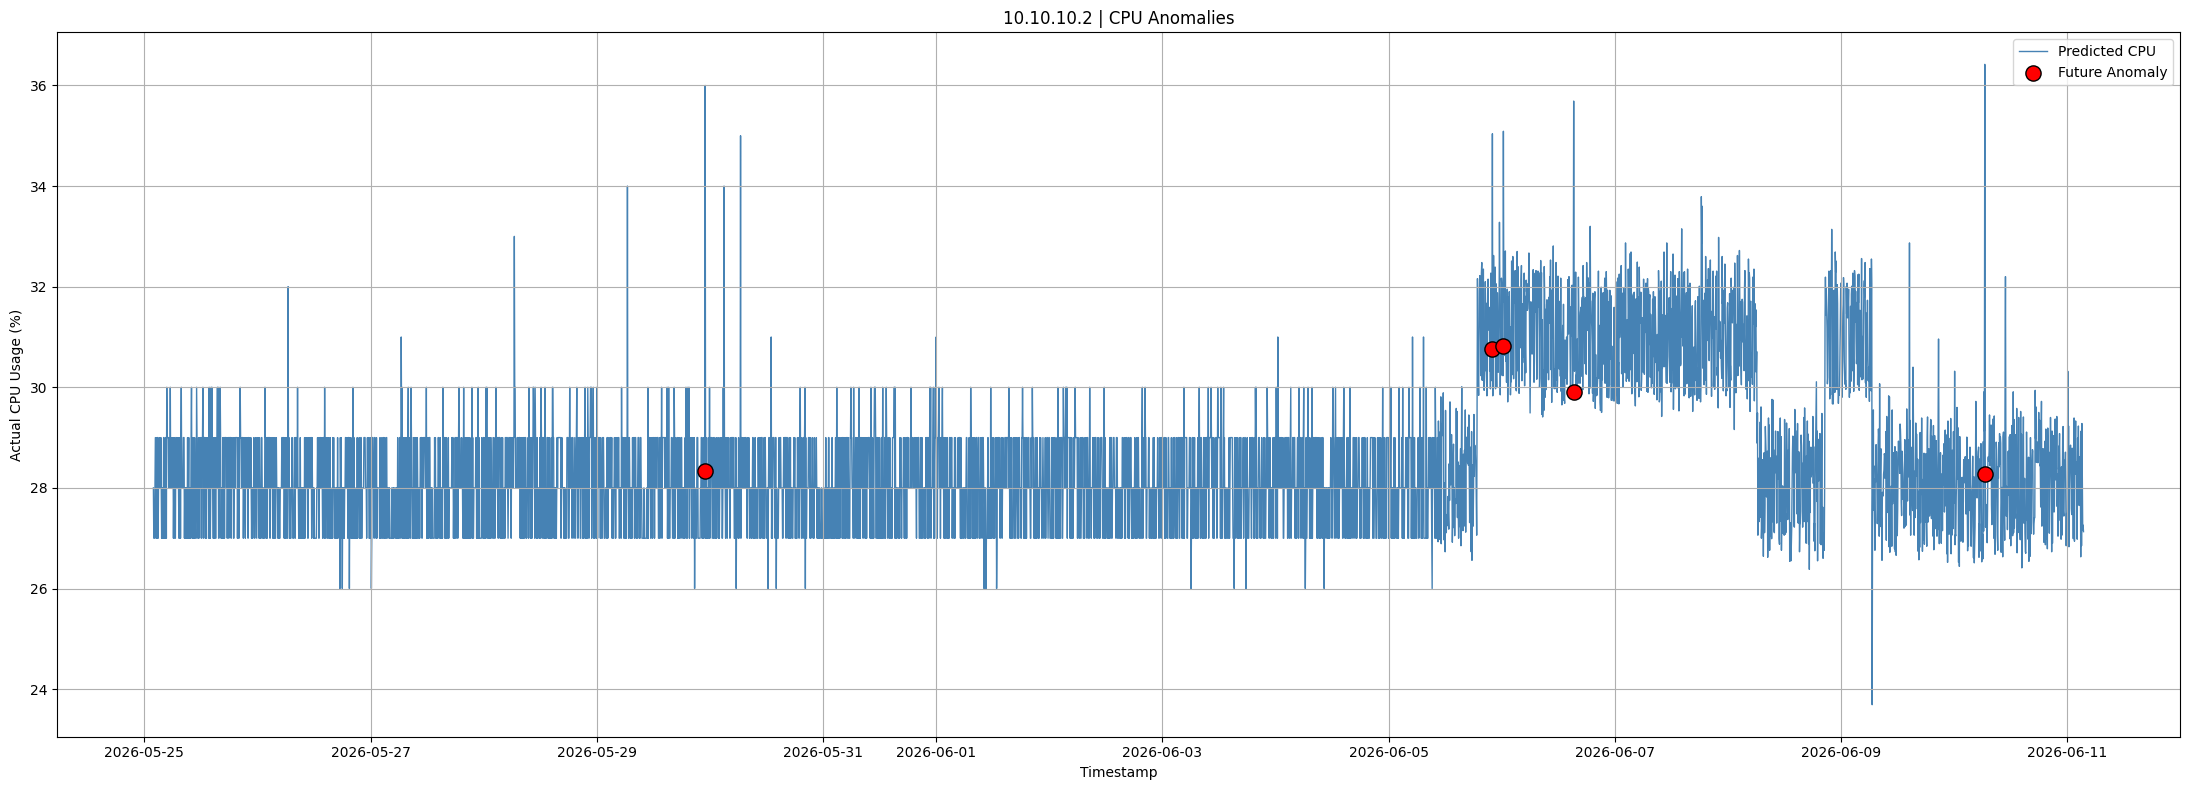

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(22,8))

plt.plot(
    df['ts'],
    df['Actual_1hr'],
    color='steelblue',
    linewidth=1,
    label='Predicted CPU',
    zorder=1
)

plt.scatter(
    df.loc[df['iso_anomaly'], 'ts'],
    df.loc[df['iso_anomaly'], 'Predicted_1hr'],
    color='red',
    marker='o',
    s=120,
    edgecolors='black',
    linewidths=1,
    zorder=20,
    label='Future Anomaly'
)

plt.title(
    f'{SERVER_NAME} | CPU Anomalies'
)

plt.xlabel('Timestamp')
plt.ylabel('Actual CPU Usage (%)')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

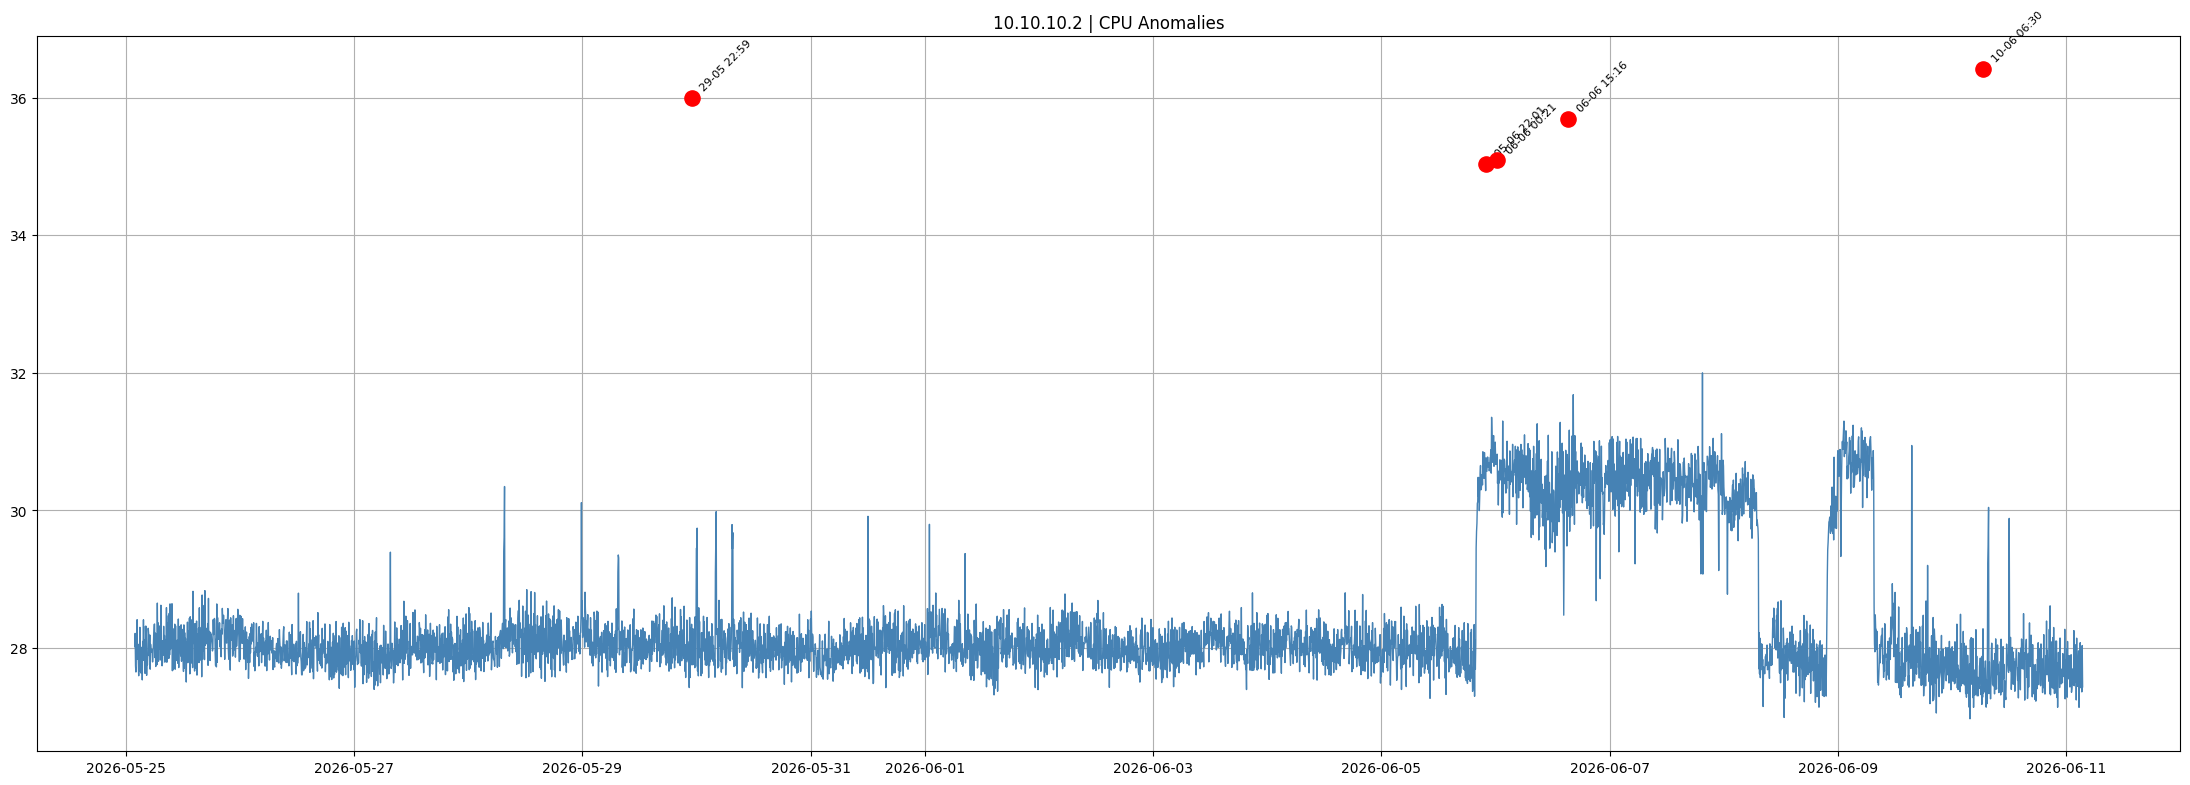

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(22,8))
plt.plot(
    df['ts'],
    df['Predicted_1hr'],
    color='steelblue',
    linewidth=1
)
anomalies = df[
    df['iso_anomaly']
]

plt.scatter(
    anomalies['ts'],
    anomalies['Actual_1hr'],
    color='red',
    s=120,
    zorder=20
)

for _, row in anomalies.iterrows():

    plt.annotate(
        row['ts'].strftime('%d-%m %H:%M'),
        (
            row['ts'],
            row['Actual_1hr']
        ),
        fontsize=8,
        rotation=45,
        xytext=(5,5),
        textcoords='offset points'
    )

plt.title(
    f'{SERVER_NAME} | CPU Anomalies'
)

plt.grid(True)

plt.tight_layout()

plt.show()

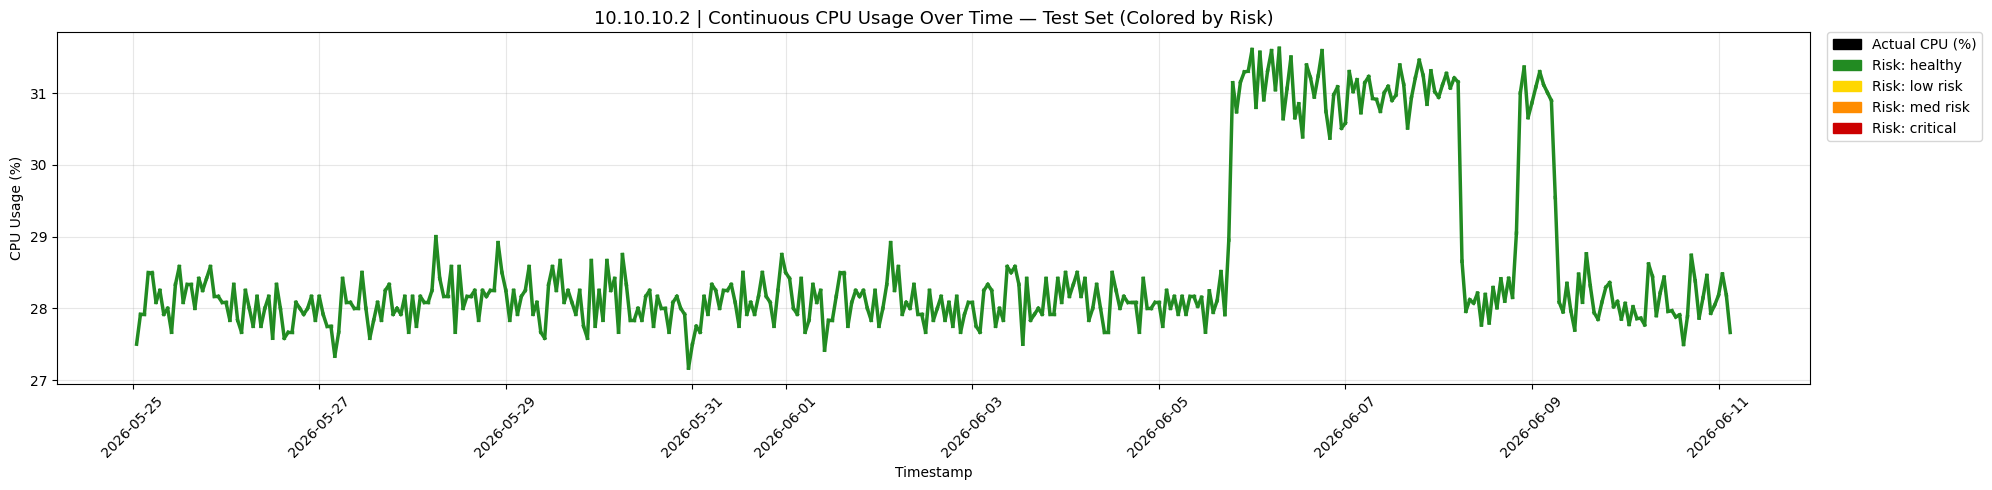

In [14]:
# =====================================
# RISK ANALYSIS — Clean Single Line, Test Set (Actual_1hr)
# =====================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def get_cpu_risk(cpu_val):
    if cpu_val >= 90:   return 'critical'
    elif cpu_val >= 75: return 'med risk'
    elif cpu_val >= 60: return 'low risk'
    else:               return 'healthy'

RISK_COLORS = {
    'healthy':  '#228B22',
    'low risk': '#FFD700',
    'med risk': '#FF8C00',
    'critical': '#CC0000',
}

# Resample to hourly to get a clean single line
plot_df = (
    df.set_index('ts')['Actual_1hr']
    .resample('1h').mean()
    .dropna()
    .reset_index()
)
plot_df.columns = ['ts', 'Actual_1hr']
plot_df['risk'] = plot_df['Actual_1hr'].apply(get_cpu_risk)

fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(plot_df['ts'], plot_df['Actual_1hr'],
        color='black', linewidth=1.2, zorder=1)

for i in range(len(plot_df) - 1):
    risk = plot_df['risk'].iloc[i]
    ax.plot(
        plot_df['ts'].iloc[i:i+2],
        plot_df['Actual_1hr'].iloc[i:i+2],
        color=RISK_COLORS[risk], linewidth=2.5, zorder=2
    )

patches = [mpatches.Patch(color='black', label='Actual CPU (%)')]
for label, color in RISK_COLORS.items():
    patches.append(mpatches.Patch(color=color, label=f'Risk: {label}'))

ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.set_title(f'{SERVER_NAME} | Continuous CPU Usage Over Time — Test Set (Colored by Risk)', fontsize=13)
ax.set_xlabel('Timestamp')
ax.set_ylabel('CPU Usage (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

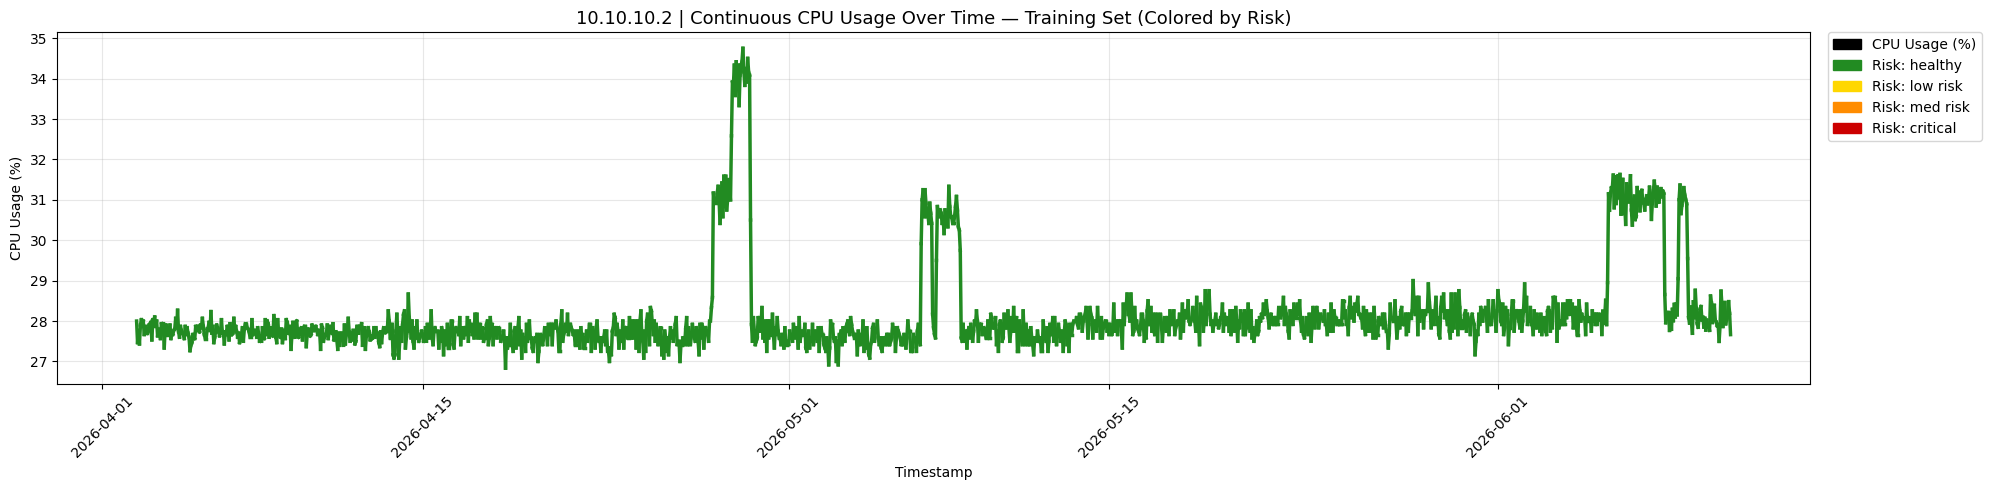

In [15]:
# =====================================
# RISK ANALYSIS — Clean Single Line, Training Set (cpu_baseline.csv)
# =====================================

# Load the raw baseline data
train_df = pd.read_csv(
    r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv"
)
train_df['ts'] = pd.to_datetime(train_df['ts'], format='mixed', utc=True)
train_df = train_df[train_df['host_id'] == SERVER_ID].sort_values('ts')

# Resample to hourly
train_plot = (
    train_df.set_index('ts')['cpu_usage_pct']
    .resample('1h').mean()
    .dropna()
    .reset_index()
)
train_plot.columns = ['ts', 'cpu_usage_pct']
train_plot['risk'] = train_plot['cpu_usage_pct'].apply(get_cpu_risk)

fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(train_plot['ts'], train_plot['cpu_usage_pct'],
        color='black', linewidth=1.2, zorder=1)

for i in range(len(train_plot) - 1):
    risk = train_plot['risk'].iloc[i]
    ax.plot(
        train_plot['ts'].iloc[i:i+2],
        train_plot['cpu_usage_pct'].iloc[i:i+2],
        color=RISK_COLORS[risk], linewidth=2.5, zorder=2
    )

patches = [mpatches.Patch(color='black', label='CPU Usage (%)')]
for label, color in RISK_COLORS.items():
    patches.append(mpatches.Patch(color=color, label=f'Risk: {label}'))

ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax.set_title(f'{SERVER_NAME} | Continuous CPU Usage Over Time — Training Set (Colored by Risk)', fontsize=13)
ax.set_xlabel('Timestamp')
ax.set_ylabel('CPU Usage (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()